# Implementation of MCP Neuron for AND and OR Function.

In [13]:
import numpy as np
import matplotlib as mp
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.

    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.

    Output:
    state_neuron (1D list): State of neuron (1 or 0) for the given inputs.
    """
    assert len(X1) == len(X2)

    # Create a list to store outputs
    state_neuron = []

    # Element-wise addition and threshold check
    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [4]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [5]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.

    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.

    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)

    # Create a list to store outputs
    state_neuron = []

    # Element-wise addition and threshold check
    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [6]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


3.2.1 Answer the Following Question:
• You can use Text cell of your notebook to answer the question.

• Question - 1: List out all the limitations of MCP - Neurons.
1) Computational Intensity: Training large neural networks demands immense processing power (GPUs/TPUs).
2) Data Hunger: Neural networks require massive labeled datasets to learn effectively, unlike humans who can learn from few examples.
3) Black Box Problem: It is difficult to interpret how networks reach decisions, making them unreliable in fields requiring transparency.


• Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

A single MCP neuron cannot solve the XOR function because it is not linearly separable. However, XOR can be implemented by combining multiple MCP neurons. The logic is simple: the output is 1 when the two inputs are different, and 0 when they are the same. This can be expressed using if-else rules or by combining basic operations like OR and AND, where XOR = OR − AND or equivalently (X1 OR X2) AND NOT (X1 AND X2).

Task 2: Perceptron Algorithm for 0 vs 1 Classification.

# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labelsz
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


Answer the Following Question:

Question - 1: What does the shape of X represent?

  The shape of the X represents the rows and columns of the dataset.


Question - 2: What does the shape of y represent?

The shape of the y represent rows and columns

### Viewing the Dataset.

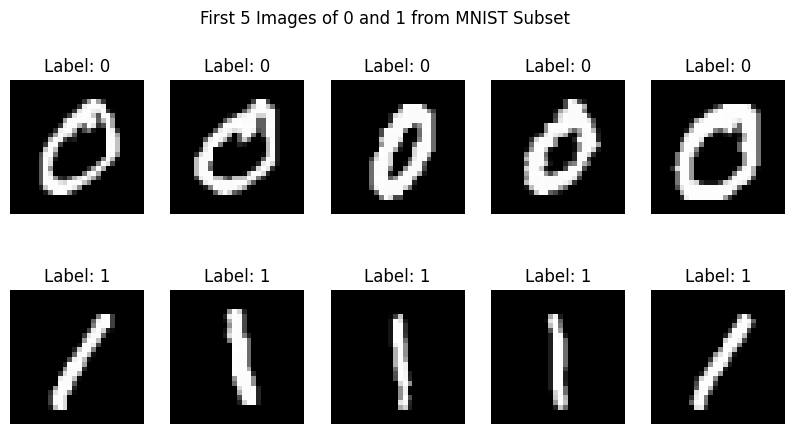

In [14]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [15]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Answer the Following Question:

Question - 3: What does the weights array represent in this context?

Weights array represents the importance of each input features(pixels) in making a predictions.


Question - 4: Why are we initializing the weights to zero? What effect could this
have on the training process?

We initialized the weights to zero as it provide equal importance with a simple and neutral starting point.

In the case of a perceptron, this does not prevent learning because the weights are updated based on errors for each training example, gradually adjusting to meaningful values.


## Step - 3 - Make a Decision function:

In [16]:
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias

    # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [17]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    """

    for _ in range(epochs):
        for i in range(len(X)):
            # Linear combination
            linear_output = np.dot(X[i], weights) + bias

            # Step activation
            y_pred = 1 if linear_output >= 0 else 0

            # Update rule
            error = y[i] - y_pred
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error

    # Calculate accuracy
    y_pred_all = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy = np.sum(y_pred_all == y)

    return weights, bias, accuracy

Answer the Following Question:

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

It sums up the contributions of each feature (pixel) scaled by its weight and adds the bias term. This value represents the activation level of the neuron before applying the step (or other) activation function, which then determines the predicted output (0 or 1). It is essentially the core computation of the perceptron.




Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?

When the perceptron makes a wrong prediction, it adjusts the weights and bias to reduce the error. The weights are updated proportionally to the input values and the error, and the bias is adjusted by the error as well. This helps the perceptron gradually learn the correct decision boundary and improve its predictions over time.


Question - 7:Why is the final accuracy important, and what do you expect it to be?

Final accurancy is important beacuse it shows the overall performance of the model and also how trained our input data is on perception. For a simple perceptron trained on linearly separable data, you would expect high accuracy (close to 100%), but for datasets that are more complex, like MNIST digits, a single-layer perceptron might achieve moderate accuracy, typically around 85–90%, because it cannot capture highly non-linear patterns.

## Training the Perceptron

In [18]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  12665


## Step 5: Visualize Misclassified Images

In [19]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


In [20]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Answer the Following Question:

Question - 8:What does misclassified idx store, and how is it used in this code?

Misclassified idx store the indices of all the data points where the predicted label doesn't match the true label.

In this code it is used to visualize the misclassified images.

Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?

If the output is “All images were correctly classified!”, it means that the perceptron predicted every sample in the dataset correctly, achieving 100% accuracy. This indicates that the model has perfectly learned the patterns in the training data.

#Task 3: Perceptron Algorithm for 3 vs 5 Classification.

In [25]:
df_0_1 = pd.read_csv("/content/drive/MyDrive/mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


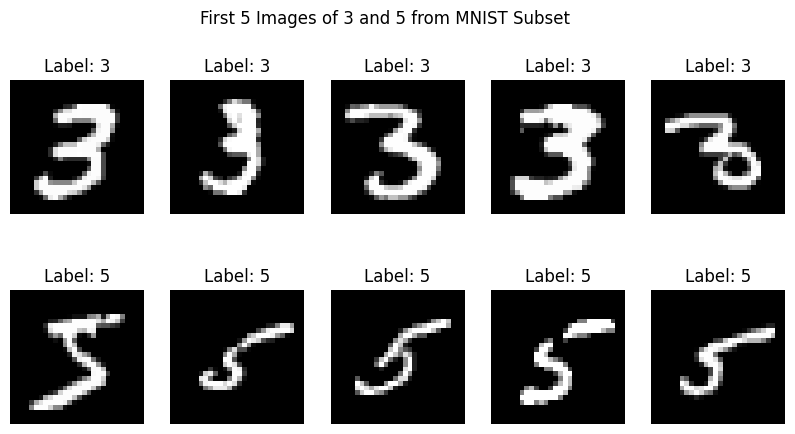

In [26]:
# Separate images for label 0 and label 1
images_3 = X[y == 3]  # Get all images with label 0
images_5 = X[y == 5]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_3 or images_5 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 3
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")
        # Plot digit 5
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()

In [28]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

In [29]:
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 3, 5, 3)
    return y_pred_all

In [30]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    for epoch in range(epochs):
        predictions = np.dot(X, weights) + bias
        y_pred_all = np.where(predictions >= 3, 5, 3)
        error = y - y_pred_all
        weights += learning_rate * np.dot(X.T, error)
        bias += learning_rate * np.sum(error)
        accuracy = np.mean(y_pred_all == y)
    return weights, bias, accuracy

In [31]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)

# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.9595038307187158


Final Accuracy: 0.9577


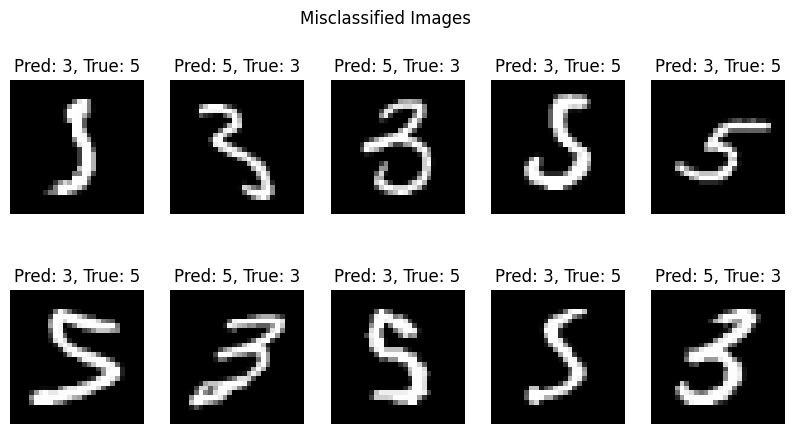

In [33]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 3, 5, 3)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

The Perceptron model was able to classify digits 3 and 5 with moderate accuracy, but some errors remained. The misclassified images were mostly unclear or looked similar, making them hard to distinguish.

This shows that the Perceptron struggles with complex patterns because it only works well for linearly separable data. Therefore, more advanced models like neural networks would perform better for this task.